In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)

## Exp. Design
Write some text about experimental design

## Performance Metrics

#### Learning
Start simple, lets look at trials across learning between conditions & in expert behaviour (when stim starts)

In [3]:
from GridMaze.analysis.behaviour import learning as bl

learning_df = bl.get_learning_curve_df()
expert_df = bl.get_expert_performance_df()

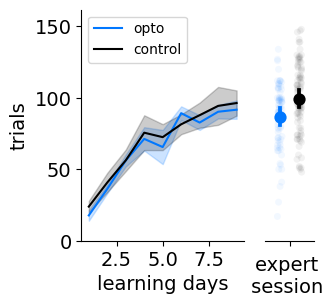

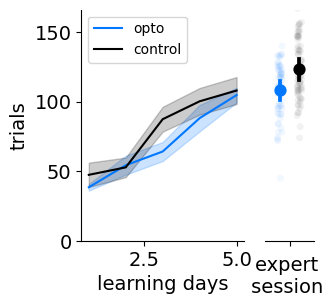

In [4]:
reload(bl)
for maze_order in [1, 2]:
    fig, axes = plt.subplots(1, 2, figsize=(3, 3), width_ratios=[1, 0.3], sharey=True)
    bl.plot_performance_summary(learning_df, expert_df, maze_order=maze_order, print_stats=False, axes=axes)
    fig.savefig(f"../results/figures/learning_maze_order_{maze_order}.pdf")

#### Excess steps (during expert behaviour with mFC inhibition)

In [5]:
import numpy as np
from GridMaze.analysis.behaviour import excess_steps as es

excess_steps_df = es.get_excess_steps_df(verbose=False)

In [6]:
excess_steps_df.total_stim_days.max()

22

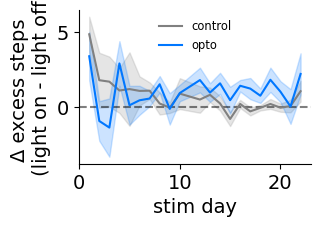

In [11]:
reload(es)
f, ax = plt.subplots(1, 1, figsize=(3, 2))
es.plot_stim_effects_over_days(excess_steps_df, outlier_thres=200, rolling_avg=False, ax=ax)
f.savefig("../results/figures/delta_excess_steps_over_time.pdf")

        Source         SS  DF1  DF2         MS          F     p-unc       np2  \
0    condition  10.465058    1   13  10.465058  10.742735  0.006001  0.452464   
1   stim_trial   3.773518    1   13   3.773518  25.585997  0.000219  0.663090   
2  Interaction   2.450776    1   13   2.450776  16.617265  0.001310  0.561067   

   eps  
0  NaN  
1  1.0  
2  NaN  


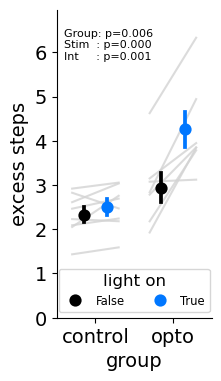

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(2, 4))
es.plot_random_effects_summary(
    excess_steps_df,
    stim_day_range=(8, 22),
    outlier_thres=500,
    print_stats=True,
    ax=ax,
)
fig.savefig("../results/figures/random_effects_excess_steps.pdf")

### Example trajectory plots

In [ ]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

session = gs.get_maze_sessions(subject_IDs=["mFC-opto_23"], maze_names=["maze_2"], days_on_maze=[9])[0]

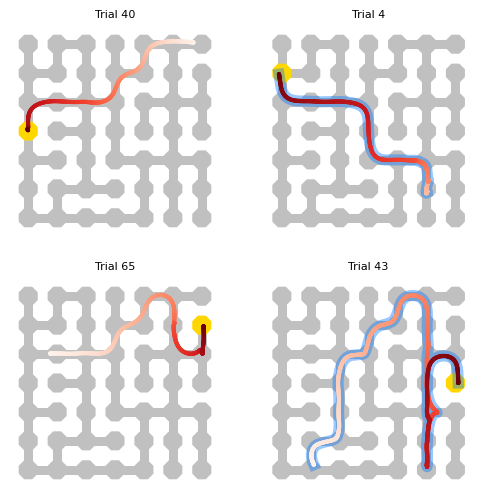

In [ ]:
f, axes = plt.subplots(2, 2, figsize=(6, 6))
for ax, t in zip(axes.flatten(), [40, 4, 65, 43]):
    tp.plot_fancy_trial_trajectory(session, trial=t, ax=ax)
f.savefig("../results/figures/opto_trajectory_examples.pdf")

In [22]:
session2 = gs.get_maze_sessions(subject_IDs=["mFC-opto_26"], total_stim_days=[17])[0]

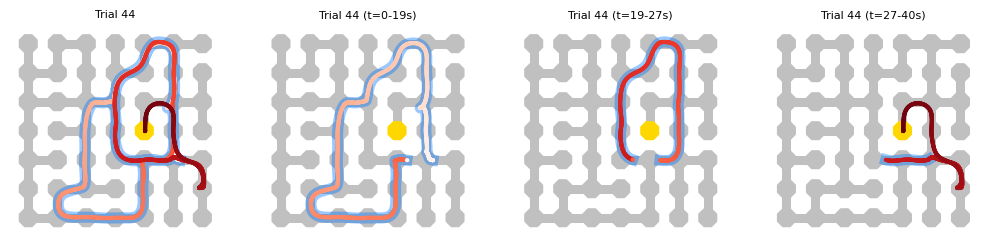

In [ ]:
# another example disrupted nav trial in opto subject
reload(tp)
trial = 44
f, axes = plt.subplots(1, 4, figsize=(12.5, 3.5))
for ax, t_range in zip(axes, [None, (0, 19), (19, 27), (27, 40)]):
    tp.plot_fancy_trial_trajectory(session2, trial=trial, t_range=t_range, ax=ax)